# LSTM for Sentiment Classification

In this notebook we build an LSTM model to classify tweets as **Positive** or **Negative**.

We will cover:
1. **Data loading and EDA** - understanding the dataset before modeling
2. **Text preprocessing** - cleaning text for neural network input
3. **Tokenization and padding** - converting text to fixed-length integer sequences
4. **Pre-trained embeddings** - using GloVe to initialize the embedding layer
5. **Model architecture** - building an LSTM with proper regularization
6. **Training with callbacks** - early stopping and checkpointing
7. **Evaluation** - using metrics appropriate for imbalanced datasets
8. **Inference** - predicting sentiment on new text

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nluninja/text-mining-dataviz-aa2526/blob/main/05-LSTM/NLP05-02_LSTM-for-Classification.ipynb)

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 821.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 20.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


---
## 1. Data Loading

We load a dataset of tweets labeled with sentiment (Positive, Negative, Neutral).
We keep only the `text` and `sentiment` columns - the rest are not needed for this task.

In [5]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/nluninja/text-mining-dataviz-aa2526/refs/heads/main/05-LSTM/Sentiment_.csv'
)
data = data[['text', 'sentiment']]
print(f'Dataset shape: {data.shape}')
data.head()

Dataset shape: (13871, 2)


,text,sentiment
0,RT @NancyLeeGrahn: How did everyone feel about...,Neutral
1,RT @ScottWalker: Didn't catch the full #GOPdeb...,Positive
2,RT @TJMShow: No mention of Tamir Rice and the ...,Neutral
3,RT @RobGeorge: That Carly Fiorina is trending ...,Positive
4,RT @DanScavino: #GOPDebate w/ @realDonaldTrump...,Positive


---
## 2. Exploratory Data Analysis (EDA)

Before any modeling, we need to understand our data:
- How many samples per class?
- Is the dataset balanced?
- How long are the tweets?

These observations will guide our preprocessing and modeling choices.

Class distribution (all 3 classes):
sentiment
Negative    8493
Neutral     3142
Positive    2236
Name: count, dtype: int64



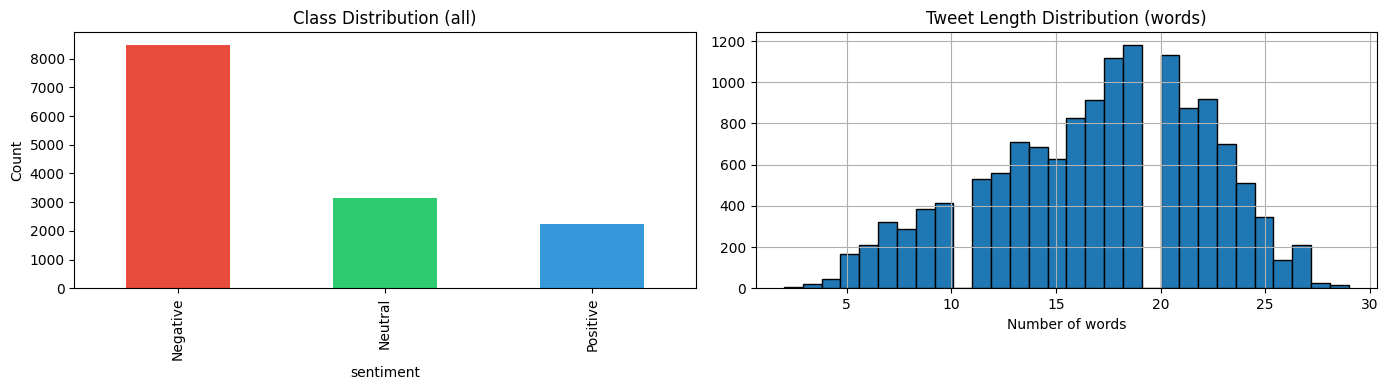


Text length stats:
count    13871.000000
mean        16.943912
std          5.224908
min          2.000000
25%         13.000000
50%         18.000000
75%         21.000000
max         29.000000
Name: text_len, dtype: float64


In [6]:
# Class distribution
print('Class distribution (all 3 classes):')
print(data['sentiment'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71', '#3498db'])
axes[0].set_title('Class Distribution (all)')
axes[0].set_ylabel('Count')

# Text length distribution
data['text_len'] = data['text'].apply(lambda x: len(str(x).split()))
data['text_len'].hist(bins=30, ax=axes[1], edgecolor='black')
axes[1].set_title('Tweet Length Distribution (words)')
axes[1].set_xlabel('Number of words')

plt.tight_layout()
plt.show()

print(f'\nText length stats:')
print(data['text_len'].describe())

### Filtering: removing Neutral class

We simplify the task to **binary classification** (Positive vs Negative) by removing the Neutral class.
This is a deliberate choice: neutral tweets are often ambiguous and harder to define consistently.

**Important**: after filtering, we need to check the class balance again - it will likely be imbalanced.

In [8]:
data = data[data['sentiment'] != 'Neutral'].copy()
data.reset_index(drop=True, inplace=True)

print('Class distribution after filtering:')
print(data['sentiment'].value_counts())
print()

neg_count = (data['sentiment'] == 'Negative').sum()
pos_count = (data['sentiment'] == 'Positive').sum()
ratio = neg_count / pos_count
print(f'Imbalance ratio (Negative/Positive): {ratio:.1f}:1')
print(f'Positive class is only {pos_count/(neg_count+pos_count)*100:.1f}% of the data')
print()
print('>>> The dataset is IMBALANCED. We will need to account for this during training and evaluation.')

Class distribution after filtering:
sentiment
Negative    8493
Positive    2236
Name: count, dtype: int64

Imbalance ratio (Negative/Positive): 3.8:1
Positive class is only 20.8% of the data

>>> The dataset is IMBALANCED. We will need to account for this during training and evaluation.


---
## 3. Text Preprocessing

Each step has a specific reason:

1. **Lowercasing**: "Great" and "great" should be the same token. Without this, the vocabulary is unnecessarily large and the model sees them as different words.

2. **Remove special characters**: punctuation, URLs, mentions (@user), hashtag symbols don't carry sentiment information for our model. The regex `[^a-zA-Z0-9\s]` keeps only letters, digits, and spaces.

3. **Remove "rt"**: Twitter retweet markers ("RT") are formatting artifacts, not content. They appear frequently and would pollute the model's vocabulary.

In [9]:
# Show a sample before preprocessing
print('Before preprocessing:')
print(data['text'].iloc[0])
print()

# Step 1: Lowercasing
data['text'] = data['text'].str.lower()

# Step 2: Remove special characters (keep only alphanumeric + spaces)
data['text'] = data['text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

# Step 3: Remove 'rt' retweet marker
data['text'] = data['text'].str.replace('rt ', ' ', regex=False)

# Remove extra whitespace
data['text'] = data['text'].str.strip().str.replace(r'\s+', ' ', regex=True)

print('After preprocessing:')
print(data['text'].iloc[0])

Before preprocessing:
RT @ScottWalker: Didn't catch the full #GOPdebate last night. Here are some of Scott's best lines in 90 seconds. #Walker16 http://t.co/ZSfF…

After preprocessing:
scottwalker didnt catch the full gopdebate last night here are some of scotts best lines in 90 seconds walker16 httptcozsff


---
## 4. Tokenization

Neural networks work with numbers, not text. We need to:
1. Build a **vocabulary**: assign a unique integer to each word
2. Convert each tweet to a **sequence of integers**

Keras `Tokenizer` does both: it counts word frequencies, builds the index, and converts texts to sequences.

**Note**: we fit the tokenizer only on **training data** (after the split). Fitting on all data is a subtle form of **data leakage** - the tokenizer would learn vocabulary statistics from the test set. In practice for this dataset the effect is small, but it's a good habit.

In [10]:
# Encode labels as integers: Negative=0, Positive=1
# Using explicit mapping instead of pd.get_dummies to control which class is 0/1
label_map = {'Negative': 0, 'Positive': 1}
y = data['sentiment'].map(label_map).values

print(f'Label mapping: {label_map}')
print(f'Label distribution: Negative={np.sum(y==0)}, Positive={np.sum(y==1)}')

Label mapping: {'Negative': 0, 'Positive': 1}
Label distribution: Negative=8493, Positive=2236


In [11]:
# --- Split FIRST, then fit tokenizer ---
# We use stratify=y to preserve class proportions in each split
X_texts = data['text'].values

X_train_texts, X_temp_texts, y_train, y_temp = train_test_split(
    X_texts, y, test_size=0.3, random_state=42, stratify=y
)
X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_temp_texts, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train_texts)} samples')
print(f'Val:   {len(X_val_texts)} samples')
print(f'Test:  {len(X_test_texts)} samples')
print()
print(f'Train class balance: Neg={np.sum(y_train==0)}, Pos={np.sum(y_train==1)} '
      f'({np.sum(y_train==1)/len(y_train)*100:.1f}% positive)')
print(f'Test  class balance: Neg={np.sum(y_test==0)}, Pos={np.sum(y_test==1)} '
      f'({np.sum(y_test==1)/len(y_test)*100:.1f}% positive)')

Train: 7510 samples
Val:   1609 samples
Test:  1610 samples

Train class balance: Neg=5945, Pos=1565 (20.8% positive)
Test  class balance: Neg=1274, Pos=336 (20.9% positive)


In [12]:
# Fit tokenizer on TRAINING data only
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_texts)

vocabulary_size = len(tokenizer.word_index)
print(f'Vocabulary size: {vocabulary_size} unique tokens')

Vocabulary size: 12542 unique tokens


In [13]:
# Convert texts to integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train_texts)
val_sequences = tokenizer.texts_to_sequences(X_val_texts)
test_sequences = tokenizer.texts_to_sequences(X_test_texts)

# Inspect an example
print('Original text:', X_train_texts[0])
print('Sequence:     ', train_sequences[0])
print()
for idx in train_sequences[0]:
    print(f'  {idx:5d} -> {tokenizer.index_word[idx]}')

Original text: good job you have just stooped to the level of the two biggest jack asses in entertainment gopdebate httpstcounbe3hin5v
Sequence:      [136, 115, 11, 28, 38, 4966, 4, 1, 3321, 6, 1, 343, 372, 3322, 2578, 12, 1023, 2, 4967]

    136 -> good
    115 -> job
     11 -> you
     28 -> have
     38 -> just
   4966 -> stooped
      4 -> to
      1 -> the
   3321 -> level
      6 -> of
      1 -> the
    343 -> two
    372 -> biggest
   3322 -> jack
   2578 -> asses
     12 -> in
   1023 -> entertainment
      2 -> gopdebate
   4967 -> httpstcounbe3hin5v


## 5. Sequence Padding

LSTM expects inputs of **fixed length**. Since tweets have different lengths, we need to:
- **Pad** shorter sequences with zeros (the model learns to ignore padding)
- **Truncate** longer sequences that exceed our chosen max length

To choose `max_sequence_len`, we look at the length distribution. We want to cover most tweets without wasting computation on excessive padding.

In [14]:
# Analyze sequence lengths to choose max_sequence_len
seq_lengths = np.array([len(s) for s in train_sequences])
print(f'Sequence length stats (training set):')
print(f'  Min: {seq_lengths.min()}')
print(f'  Max: {seq_lengths.max()}')
print(f'  Mean: {seq_lengths.mean():.1f}')
print(f'  Median: {np.median(seq_lengths):.0f}')
print()
print('Percentiles:')
for p in [75, 80, 85, 90, 95, 99, 100]:
    print(f'  {p}%: {np.percentile(seq_lengths, p):.0f}')

Sequence length stats (training set):
  Min: 2
  Max: 29
  Mean: 16.6
  Median: 17

Percentiles:
  75%: 20
  80%: 21
  85%: 21
  90%: 22
  95%: 24
  99%: 26
  100%: 29


In [15]:
# We choose max_sequence_len = 30 (covers 100% of tweets in this dataset)
MAX_SEQUENCE_LEN = 30

# padding='pre' pads at the beginning: [0, 0, 0, ..., w1, w2, w3]
# This is generally better for LSTMs because the actual content is closer
# to the output layer, reducing the vanishing gradient problem.
X_train = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LEN, padding='pre', truncating='post')
X_val = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LEN, padding='pre', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LEN, padding='pre', truncating='post')

# One-hot encode labels for categorical crossentropy
Y_train = to_categorical(y_train, num_classes=2)
Y_val = to_categorical(y_val, num_classes=2)
Y_test = to_categorical(y_test, num_classes=2)

print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')
print()
print(f'Example padded sequence: {X_train[0]}')
print(f'Example label (one-hot): {Y_train[0]}')

X_train shape: (7510, 30)
Y_train shape: (7510, 2)
X_val shape:   (1609, 30)
X_test shape:  (1610, 30)

Example padded sequence: [   0    0    0    0    0    0    0    0    0    0    0  136  115   11
   28   38 4966    4    1 3321    6    1  343  372 3322 2578   12 1023
    2 4967]
Example label (one-hot): [1. 0.]


---
## 6. Pre-trained Word Embeddings (GloVe)

Instead of learning word representations from scratch (which requires a lot of data), we initialize our embedding layer with **GloVe** vectors.

**GloVe** (Global Vectors for Word Representation) was trained on 6 billion tokens from Wikipedia and Gigaword. Each word is represented as a 100-dimensional vector that captures semantic relationships (e.g., `king - man + woman ≈ queen`).

**Why this helps**: our dataset has ~10K samples - not enough to learn good embeddings from scratch. GloVe gives us a strong starting point. We set `trainable=True` to allow fine-tuning on our specific task.

In [16]:
import os, urllib.request, zipfile

EMBED_DIM = 100
GLOVE_PATH = 'glove.6B.100d.txt'

# Download GloVe if not present
if not os.path.isfile(GLOVE_PATH):
    print('Downloading GloVe embeddings (~822 MB)...')
    zip_path = 'glove.6B.zip'
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.100d.txt')
    os.remove(zip_path)
    # Clean up other dimensions we don't need
    for f in ['glove.6B.50d.txt', 'glove.6B.200d.txt', 'glove.6B.300d.txt']:
        if os.path.exists(f):
            os.remove(f)
    print('Done.')

# Load GloVe vectors into a dictionary
embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Loaded {len(embeddings_index)} GloVe word vectors')

Done.
Loaded 400000 GloVe word vectors


In [17]:
# Build embedding matrix: row i = GloVe vector for word with index i
# Words not in GloVe will remain as zero vectors
embedding_matrix = np.zeros((vocabulary_size + 1, EMBED_DIM))
words_found = 0

for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        words_found += 1

coverage = words_found / vocabulary_size * 100
print(f'GloVe coverage: {words_found}/{vocabulary_size} words ({coverage:.1f}%)')
print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'\nNote: {vocabulary_size - words_found} words not found in GloVe (will use zero vectors).')
print('These are typically misspellings, slang, or Twitter-specific terms.')

GloVe coverage: 7395/12542 words (59.0%)
Embedding matrix shape: (12543, 100)

Note: 5147 words not found in GloVe (will use zero vectors).
These are typically misspellings, slang, or Twitter-specific terms.


---
## 7. Model Architecture

Our model is a simple but effective architecture for text classification:

```
Input (integer sequence) → Embedding → SpatialDropout1D → LSTM → Dense (softmax)
```

**Layer-by-layer explanation**:

| Layer | Purpose | Key parameters |
|-------|---------|----------------|
| **Embedding** | Converts word indices to dense vectors | `EMBED_DIM=100`, initialized with GloVe, `trainable=True` to fine-tune |
| **SpatialDropout1D** | Drops entire embedding dimensions (not individual values). More effective than regular Dropout for sequences because it prevents co-adaptation of features across time steps | `rate=0.3` |
| **LSTM** | Processes the sequence and produces a fixed-size representation | `units=64`, `dropout=0.2` (input), `recurrent_dropout=0.2` (hidden state) |
| **Dense** | Classification layer | `units=2` (Neg/Pos), `softmax` activation |

**Why these hyperparameters?**
- `LSTM units=64`: our dataset is small (~7.5K training samples). A larger LSTM (128, 256) would overfit. Start small.
- `dropout=0.2`: moderate regularization. LSTM already has recurrent_dropout.
- `SpatialDropout1D(0.3)`: slightly higher than LSTM dropout because the embedding layer has many parameters.

In [18]:
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=vocabulary_size + 1,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=True
    ),
    SpatialDropout1D(0.3),
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dense(2, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,254,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,300 (4.78 MB)

 Trainable params: 1,254,300 (4.78 MB)

 Non-trainable params: 0 (0.00 B)

---
## 8. Handling Class Imbalance

Our dataset has ~3.8x more Negative than Positive samples. If we train without accounting for this, the model will:
- Predict "Negative" most of the time (safe bet: 79% accuracy just by always predicting Negative)
- Have poor recall on the minority class (Positive)

**Solution: `class_weight`** tells Keras to weight the loss function inversely proportional to class frequency. This means:
- A misclassified Positive sample penalizes the model **more** than a misclassified Negative sample
- The model is incentivized to learn both classes equally well

In [19]:
# Compute class weights inversely proportional to class frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f'Class weights:')
print(f'  Negative (0): {class_weights[0]:.3f}')
print(f'  Positive (1): {class_weights[1]:.3f}')
print(f'\nThe Positive class will be weighted ~{class_weights[1]/class_weights[0]:.1f}x more in the loss function.')

Class weights:
  Negative (0): 0.632
  Positive (1): 2.399

The Positive class will be weighted ~3.8x more in the loss function.


---
## 9. Training

We use two important **callbacks**:

1. **EarlyStopping**: monitors `val_loss` and stops training when it stops improving. This prevents overfitting (the model keeps improving on training data but gets worse on unseen data). `patience=3` means we wait 3 epochs without improvement before stopping. `restore_best_weights=True` ensures we keep the best model, not the last one.

2. **ModelCheckpoint**: saves the best model weights to disk. Useful if training is interrupted.

We also pass `validation_data` to monitor the model's performance on unseen data during training. This is **critical** - without it, we have no way to detect overfitting.

In [20]:
BATCH_SIZE = 32
EPOCHS = 20

checkpoint = ModelCheckpoint(
    'best-sentiment-model.weights.h5',
    monitor='val_loss',
    save_weights_only=True,
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=3,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stopping],
    verbose=2
)

Epoch 1/20

Epoch 1: val_loss improved from inf to 0.45226, saving model to best-sentiment-model.weights.h5
235/235 - 8s - 36ms/step - accuracy: 0.6298 - loss: 0.6362 - val_accuracy: 0.7825 - val_loss: 0.4523
Epoch 2/20

Epoch 2: val_loss did not improve from 0.45226
235/235 - 5s - 23ms/step - accuracy: 0.7714 - loss: 0.4925 - val_accuracy: 0.7278 - val_loss: 0.5559
Epoch 3/20

Epoch 3: val_loss improved from 0.45226 to 0.41496, saving model to best-sentiment-model.weights.h5
235/235 - 5s - 23ms/step - accuracy: 0.8144 - loss: 0.4040 - val_accuracy: 0.7993 - val_loss: 0.4150
Epoch 4/20

Epoch 4: val_loss improved from 0.41496 to 0.39721, saving model to best-sentiment-model.weights.h5
235/235 - 6s - 25ms/step - accuracy: 0.8704 - loss: 0.3209 - val_accuracy: 0.8167 - val_loss: 0.3972
Epoch 5/20

Epoch 5: val_loss did not improve from 0.39721
235/235 - 5s - 23ms/step - accuracy: 0.8941 - loss: 0.2664 - val_accuracy: 0.7986 - val_loss: 0.4306
Epoch 6/20

Epoch 6: val_loss did not improve

### Training Curves

Plotting training vs validation loss/accuracy helps us diagnose:
- **Overfitting**: training loss keeps decreasing but validation loss increases
- **Underfitting**: both losses are high and don't decrease
- **Good fit**: both losses decrease together and stabilize

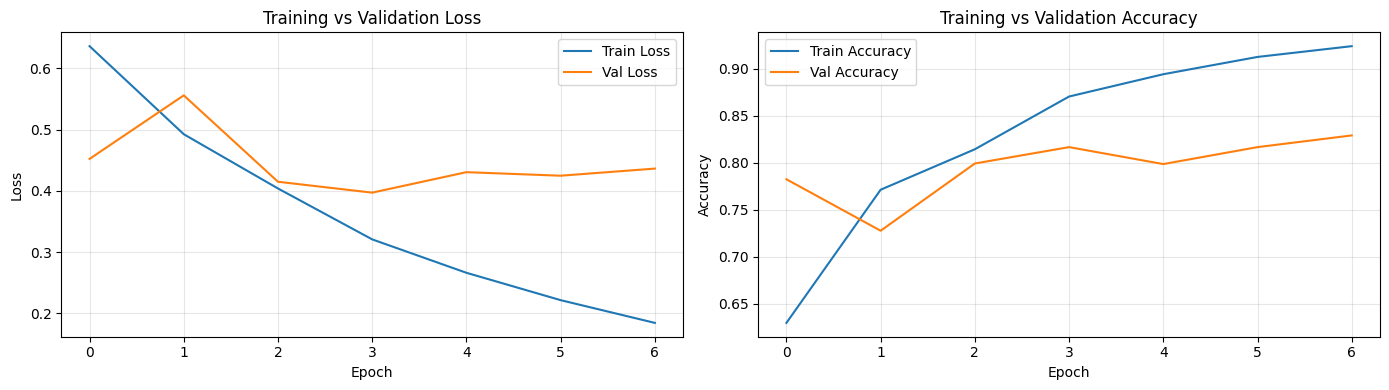

Final train loss: 0.1847
Final val loss:   0.4365
Gap: 0.2518 (possible overfitting)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for overfitting
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
gap = final_val_loss - final_train_loss
print(f'Final train loss: {final_train_loss:.4f}')
print(f'Final val loss:   {final_val_loss:.4f}')
print(f'Gap: {gap:.4f}', '(possible overfitting)' if gap > 0.2 else '(acceptable)')

---
## 10. Evaluation

For **imbalanced datasets**, accuracy alone is misleading. A model that always predicts "Negative" gets ~79% accuracy!

Better metrics:
- **Precision**: of all predicted Positives, how many are correct?
- **Recall**: of all actual Positives, how many did we find?
- **F1-score**: harmonic mean of Precision and Recall (best single metric for imbalanced data)
- **Macro avg**: average across classes (treats both classes equally, regardless of size)

In [22]:
# Predict on test set
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test, axis=1)

print('Classification Report:')
print('=' * 60)
print(classification_report(
    y_true, y_pred,
    target_names=['Negative', 'Positive'],
    digits=3
))

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative      0.927     0.823     0.872      1274
    Positive      0.529     0.753     0.622       336

    accuracy                          0.809      1610
   macro avg      0.728     0.788     0.747      1610
weighted avg      0.844     0.809     0.820      1610



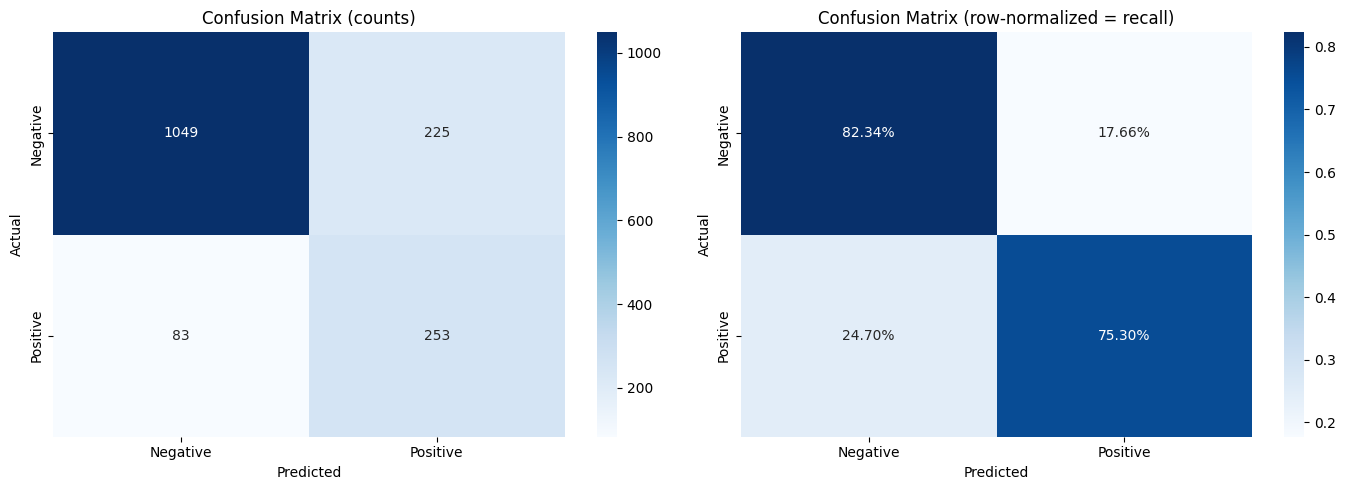

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (counts)')

# Normalized (percentages per row = recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (row-normalized = recall)')

plt.tight_layout()
plt.show()

---
## 11. Inference on New Text

To classify new text, we need to apply **exactly the same preprocessing** used during training:
1. Lowercase
2. Remove special characters
3. Tokenize using the **same tokenizer** (fitted on training data)
4. Pad to **the same length** used during training (`MAX_SEQUENCE_LEN`)

In [24]:
def predict_sentiment(text, model, tokenizer, max_len):
    """Predict sentiment for a single text string."""
    # Apply same preprocessing as training
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = text.replace('rt ', ' ').strip()

    # Tokenize and pad (same max_len as training!)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='pre', truncating='post')

    # Predict
    proba = model.predict(padded, verbose=0)[0]
    pred_class = np.argmax(proba)
    label = 'Positive' if pred_class == 1 else 'Negative'

    return label, proba


# Test on sample sentences
test_texts = [
    "I love this product, it's amazing!",
    "Terrible experience, waste of money",
    "Meetings: Because none of us is as dumb as all of us.",
    "The weather is nice today",
    "I can't believe how bad this service is",
]

print(f'{"Text":<60} {"Prediction":<12} {"Neg":>6} {"Pos":>6}')
print('=' * 88)
for text in test_texts:
    label, proba = predict_sentiment(text, model, tokenizer, MAX_SEQUENCE_LEN)
    print(f'{text:<60} {label:<12} {proba[0]:>6.3f} {proba[1]:>6.3f}')

Text                                                         Prediction      Neg    Pos
I love this product, it's amazing!                           Positive      0.072  0.928
Terrible experience, waste of money                          Negative      0.963  0.037
Meetings: Because none of us is as dumb as all of us.        Negative      0.984  0.016
The weather is nice today                                    Positive      0.102  0.898
I can't believe how bad this service is                      Negative      0.855  0.145


---
## Summary and Key Takeaways

### What we did right
- **Stratified split** to preserve class balance in train/val/test
- **Validation set** to monitor overfitting during training
- **Class weights** to handle imbalanced data
- **Early stopping** to prevent overfitting
- **Pre-trained embeddings** (GloVe) to compensate for limited training data
- **Consistent preprocessing** between training and inference
